In [2]:
import pandas as pd
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

In [3]:
df0 = pd.read_pickle("hualian_daily_gnss_dXdYdU.pkl")

In [4]:
df1 = pd.read_pickle("hualian_daily_statistics.pkl")

In [5]:
df2 = pd.read_pickle("hualian_target_cnt.pkl")

In [6]:
df2.shape

(8766,)

In [7]:
# 未來 1 天
future1 = pd.DataFrame(sliding_window_view(np.pad(df2, (0,1)), 1).sum(axis=-1)[1:], index=df2.index)
future90 = pd.DataFrame(sliding_window_view(np.pad(df2, (0,90)), 90).sum(axis=-1)[1:], index=df2.index)
future180 = pd.DataFrame(sliding_window_view(np.pad(df2, (0,180)), 180).sum(axis=-1)[1:], index=df2.index)
future365 = pd.DataFrame(sliding_window_view(np.pad(df2, (0,365)), 365).sum(axis=-1)[1:], index=df2.index)
future730 = pd.DataFrame(sliding_window_view(np.pad(df2, (0,730)), 730).sum(axis=-1)[1:], index=df2.index)

In [12]:
future1

,0
2000-01-01 00:00:00+08:00,0
2000-01-02 00:00:00+08:00,0
2000-01-03 00:00:00+08:00,0
2000-01-04 00:00:00+08:00,0
2000-01-05 00:00:00+08:00,0
...,...
2023-12-27 00:00:00+08:00,0
2023-12-28 00:00:00+08:00,0
2023-12-29 00:00:00+08:00,0
2023-12-30 00:00:00+08:00,0


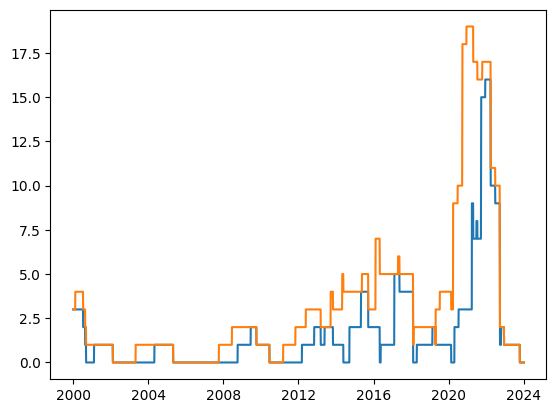

In [8]:
import matplotlib.pyplot as plt
#plt.plot(future1)
#plt.plot(future90)
#plt.plot(future180)
plt.plot(future365)
plt.plot(future730)

In [9]:
pd.Timestamp("2000-01-01") + pd.DateOffset(days=730)

Timestamp('2001-12-31 00:00:00')

In [31]:
for df in (future1, future90, future180, future365, future730):
    start = pd.Timestamp("2000-01-01", tz='Asia/Taipei') + pd.DateOffset(days=730-1)
    end = pd.Timestamp("2019-12-31", tz='Asia/Taipei')
    df = df.loc[start:end]
    days = len(df)
    cnts = (df > 0).sum().item()
    print(f"{cnts}/{days} ({cnts/days * 100:.2f}%)")
    #future1.loc['2002-01-01':'2020-01-01'].size, (future1.loc['2002-01-01':'2020-01-01'] > 0).sum()

15/6576 (0.23%)
1083/6576 (16.47%)
2163/6576 (32.89%)
3678/6576 (55.93%)
4979/6576 (75.71%)


In [30]:
future1.index[730]

Timestamp('2001-12-31 00:00:00+0800', tz='UTC+08:00')

In [22]:
df

,0
2001-12-31 00:00:00+08:00,1
2002-01-01 00:00:00+08:00,1
2002-01-02 00:00:00+08:00,1
2002-01-03 00:00:00+08:00,1
2002-01-04 00:00:00+08:00,1
...,...
2019-12-27 00:00:00+08:00,4
2019-12-28 00:00:00+08:00,4
2019-12-29 00:00:00+08:00,4
2019-12-30 00:00:00+08:00,4


In [32]:
for df in (future1, future90, future180, future365, future730):
    start = pd.Timestamp("2020-01-01", tz='Asia/Taipei') + pd.DateOffset(days=730-1)
    #end = pd.Timestamp("2020-01-01", tz='Asia/Taipei')
    df = df.loc[start: ]
    days = len(df)
    cnts = (df > 0).sum().item()
    print(f"{cnts}/{days} ({cnts/days * 100:.2f}%)")
    #future1.loc['2002-01-01':'2020-01-01'].size, (future1.loc['2002-01-01':'2020-01-01'] > 0).sum()

8/732 (1.09%)
433/732 (59.15%)
523/732 (71.45%)
650/732 (88.80%)
650/732 (88.80%)


In [20]:
df

,0
2020-01-01 00:00:00+08:00,4
2020-01-02 00:00:00+08:00,4
2020-01-03 00:00:00+08:00,4
2020-01-04 00:00:00+08:00,4
2020-01-05 00:00:00+08:00,4
...,...
2023-12-27 00:00:00+08:00,0
2023-12-28 00:00:00+08:00,0
2023-12-29 00:00:00+08:00,0
2023-12-30 00:00:00+08:00,0


In [41]:
# 
input_data = pd.concat( (df0, df1), axis=1)
output_data = df2

In [43]:
input_data_trn = input_data.loc[:'2020-01-01']
input_data_tst = input_data.loc['2020-01-01':]


In [36]:
df0.shape, df1.shape, df2.shape

((8766, 75), (8766, 6), (8766,))

In [38]:
df2.to_numpy()

array([0, 0, 0, ..., 0, 0, 0], shape=(8766,))

In [38]:
df2.to_numpy()

array([0, 0, 0, ..., 0, 0, 0], shape=(8766,))

In [34]:
pd.concat( (df0, df1), axis=1)

,"(DCHU, dX)","(DCHU, dY)","(DCHU, dU)","(FUDN, dX)","(FUDN, dY)","(FUDN, dU)","(JPEI, dX)","(JPEI, dY)","(JPEI, dU)","(SPAO, dX)",...,"(FLNM, dU)","(TUNM, dX)","(TUNM, dY)","(TUNM, dU)",極淺層-能量,淺層-能量,中層-能量,極淺層-次數,淺層-次數,中層-次數
2000-01-01 00:00:00+08:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,2.975212,-9.200000,-9.2,21.0,0.0,0.0
2000-01-02 00:00:00+08:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.03445,0.00000,0.00000,0.00000,3.081001,2.611692,-9.2,22.0,2.0,0.0
2000-01-03 00:00:00+08:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.04531,0.00000,0.00000,0.00000,4.410444,-9.200000,-9.2,26.0,0.0,0.0
2000-01-04 00:00:00+08:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.04451,0.00000,0.00000,0.00000,4.346453,-9.200000,-9.2,33.0,0.0,0.0
2000-01-05 00:00:00+08:00,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,3.896408,3.633230,-9.2,16.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27 00:00:00+08:00,0.53492,0.96359,-0.17689,0.41283,0.86322,-0.10009,0.14438,-0.09139,0.11578,0.37152,...,-0.01601,0.09307,-0.12803,0.12554,-9.200000,-9.200000,-9.2,0.0,0.0,0.0
2023-12-28 00:00:00+08:00,0.53430,0.96768,-0.17757,0.41304,0.86631,-0.11408,0.14821,-0.08682,0.12202,0.36943,...,-0.01613,0.09391,-0.12567,0.12241,-9.200000,-9.200000,-9.2,0.0,0.0,0.0
2023-12-29 00:00:00+08:00,0.53080,0.96482,-0.15862,0.40965,0.86513,-0.10730,0.15367,-0.08726,0.11962,0.37118,...,-0.01509,0.09406,-0.12641,0.13085,-9.200000,-9.200000,-9.2,0.0,0.0,0.0
2023-12-30 00:00:00+08:00,0.53441,0.96470,-0.17009,0.41256,0.86563,-0.10608,0.15114,-0.08852,0.11370,0.36889,...,-0.01891,0.09031,-0.12449,0.11596,-9.200000,-9.200000,-9.2,0.0,0.0,0.0


In [6]:
df0

station                       DCHU                       FUDN           \
coordinate                      dX       dY       dU       dX       dY   
1994-01-01 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
1994-01-02 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
1994-01-03 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
1994-01-04 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
1994-01-05 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
...                            ...      ...      ...      ...      ...   
2023-12-27 00:00:00+08:00  0.53492  0.96359 -0.17689  0.41283  0.86322   
2023-12-28 00:00:00+08:00  0.53430  0.96768 -0.17757  0.41304  0.86631   
2023-12-29 00:00:00+08:00  0.53080  0.96482 -0.15862  0.40965  0.86513   
2023-12-30 00:00:00+08:00  0.53441  0.96470 -0.17009  0.41256  0.86563   
2023-12-31 00:00:00+08:00  0.52896  0.96579 -0.17542  0.40828  0.86527   

station                                JPEI                       SPAO  ...  \
coordinate                      dU       dX       dY       dU       dX  ...   
1994-01-01 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  ...   
1994-01-02 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  ...   
1994-01-03 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  ...   
1994-01-04 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  ...   
1994-01-05 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  ...   
...                            ...      ...      ...      ...      ...  ...   
2023-12-27 00:00:00+08:00 -0.10009  0.14438 -0.09139  0.11578  0.37152  ...   
2023-12-28 00:00:00+08:00 -0.11408  0.14821 -0.08682  0.12202  0.36943  ...   
2023-12-29 00:00:00+08:00 -0.10730  0.15367 -0.08726  0.11962  0.37118  ...   
2023-12-30 00:00:00+08:00 -0.10608  0.15114 -0.08852  0.11370  0.36889  ...   
2023-12-31 00:00:00+08:00 -0.10618  0.15511 -0.09024  0.11710  0.36735  ...   

station                       JULI     DNFU                       FLNM  \
coordinate                      dU       dX       dY       dU       dX   
1994-01-01 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
1994-01-02 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
1994-01-03 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
1994-01-04 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000   
1994-01-05 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.23016   
...                            ...      ...      ...      ...      ...   
2023-12-27 00:00:00+08:00  0.84268  0.05385  0.05371  0.11392  0.05705   
2023-12-28 00:00:00+08:00  0.83817  0.05425  0.05985  0.11263  0.05855   
2023-12-29 00:00:00+08:00  0.83827  0.05235  0.05802  0.12307  0.06251   
2023-12-30 00:00:00+08:00  0.84296  0.05529  0.05671  0.12947  0.05753   
2023-12-31 00:00:00+08:00  0.83327  0.06222  0.04964  0.12624  0.06219   

station                                         TUNM                    
coordinate                      dY       dU       dX       dY       dU  
1994-01-01 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  
1994-01-02 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  
1994-01-03 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  
1994-01-04 00:00:00+08:00  0.00000  0.00000  0.00000  0.00000  0.00000  
1994-01-05 00:00:00+08:00 -0.21545  0.07208  0.00000  0.00000  0.00000  
...                            ...      ...      ...      ...      ...  
2023-12-27 00:00:00+08:00  0.03556 -0.01601  0.09307 -0.12803  0.12554  
2023-12-28 00:00:00+08:00  0.03775 -0.01613  0.09391 -0.12567  0.12241  
2023-12-29 00:00:00+08:00  0.03724 -0.01509  0.09406 -0.12641  0.13085  
2023-12-30 00:00:00+08:00  0.03784 -0.01891  0.09031 -0.12449  0.11596  
2023-12-31 00:00:00+08:00  0.03395 -0.02052  0.09816 -0.12872  0.11113  

[10957 rows x 75 columns]

In [99]:
import torch
from torch.utils.data import Dataset

ModuleNotFoundError: No module named 'torch'